In [1]:
import numpy as np
import pandas as pd
import risk_kit as rk
%load_ext autoreload
%autoreload 2

In [2]:
rk.bond_cash_flows(3, 100, 0.03, 2)

1      1.5
2      1.5
3      1.5
4      1.5
5      1.5
6    101.5
dtype: float64

In [3]:
rk.bond_price(3, 100, 0.03, 2)

np.float64(100.00000000000006)

In [4]:
rates = np.linspace(.01, .10, num = 20)
rates

array([0.01      , 0.01473684, 0.01947368, 0.02421053, 0.02894737,
       0.03368421, 0.03842105, 0.04315789, 0.04789474, 0.05263158,
       0.05736842, 0.06210526, 0.06684211, 0.07157895, 0.07631579,
       0.08105263, 0.08578947, 0.09052632, 0.09526316, 0.1       ])

In [5]:
prices = [rk.bond_price(10, 1000, .05, 2, rate) for rate in rates]
prices

[np.float64(1379.7483829333992),
 np.float64(1326.7629283179222),
 np.float64(1276.1632981372743),
 np.float64(1227.833537616068),
 np.float64(1181.6636507727876),
 np.float64(1137.5492793724407),
 np.float64(1095.3913999300185),
 np.float64(1055.0960377089511),
 np.float64(1016.5739967228162),
 np.float64(979.7406048086303),
 np.float64(944.5154728963505),
 np.float64(910.8222676519945),
 np.float64(878.5884967212596),
 np.float64(847.74530584692),
 np.float64(818.2272871767957),
 np.float64(789.9722981198867),
 np.float64(762.9212901465673),
 np.float64(737.0181469646424),
 np.float64(712.209531536784),
 np.float64(688.4447414365)]

<Axes: title={'center': 'Price of 10 y bond with diff interest rates'}>

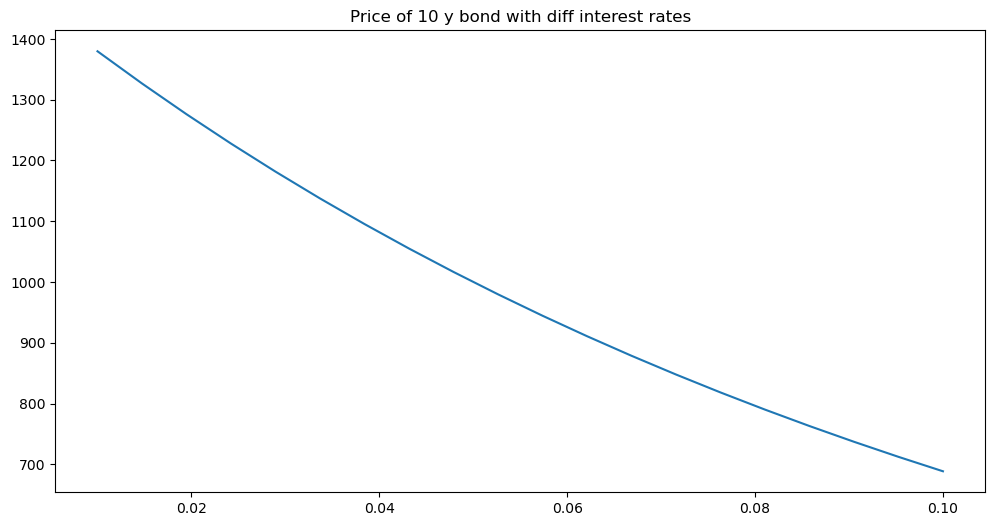

In [6]:
pd.DataFrame(data = prices, index = rates).plot(title = "Price of 10 y bond with diff interest rates", legend = False, figsize = (12, 6))

In [7]:
cf = rk.bond_cash_flows(3, 1000, .06, 2)
discounts = rk.discount(cf.index, .06 / 2)
discounts

Index([ 0.970873786407767, 0.9425959091337544, 0.9151416593531595,
       0.8884870479156888, 0.8626087843841639, 0.8374842566836542],
      dtype='float64')

In [8]:
dcf = discounts * cf
dcf

1     29.126214
2     28.277877
3     27.454250
4     26.654611
5     25.878264
6    862.608784
dtype: float64

In [9]:
weights = dcf / dcf.sum()
weights

1    0.029126
2    0.028278
3    0.027454
4    0.026655
5    0.025878
6    0.862609
dtype: float64

In [10]:
(cf.index * weights).sum() # macaulay duration

np.float64(5.579707187194534)

In [11]:
rk.macaulay_duration(rk.bond_cash_flows(3, 1000, .06, 2), .06 / 2)

np.float64(5.579707187194534)

## Duration Matching

In [13]:
liabilities = pd.Series(data = [100000, 100000], index = [10, 12])
rk.macaulay_duration(liabilities, .04)

np.float64(10.960799385088393)

In [14]:
md_10 = rk.macaulay_duration(rk.bond_cash_flows(10, 1000, .05, 1), .04)
md_20 = rk.macaulay_duration(rk.bond_cash_flows(20, 1000, .05, 1), .04)

In [15]:
md_10, md_20

(np.float64(8.190898824083233), np.float64(13.544718122145921))

$$ w_s = \frac{d_l -d_t}{d_l - d_s} $$

In [18]:
short_bond = rk.bond_cash_flows(10, 1000, .05, 1)
long_bond = rk.bond_cash_flows(20, 1000, .05, 1)
w_s = rk.match_durations(liabilities, short_bond, long_bond, 0.04)
w_s

np.float64(0.48263092069478974)

In [19]:
p_short = rk.bond_price(10, 1000, .05, 1, .04)
p_long = rk.bond_price(20, 1000, .05, 1, .04)
a_0 = 130000
p_flows = pd.concat([a_0 * w_s * short_bond / p_short, a_0 * (1 - w_s) * long_bond / p_long])
p_flows

1      2901.743586
2      2901.743586
3      2901.743586
4      2901.743586
5      2901.743586
6      2901.743586
7      2901.743586
8      2901.743586
9      2901.743586
10    60936.615315
1      2960.550536
2      2960.550536
3      2960.550536
4      2960.550536
5      2960.550536
6      2960.550536
7      2960.550536
8      2960.550536
9      2960.550536
10     2960.550536
11     2960.550536
12     2960.550536
13     2960.550536
14     2960.550536
15     2960.550536
16     2960.550536
17     2960.550536
18     2960.550536
19     2960.550536
20    62171.561257
dtype: float64

In [20]:
rk.macaulay_duration(p_flows, 0.04)

np.float64(10.960799385088393)

In [22]:
cfr = rk.funding_ratio(p_flows, liabilities, 0.04)
cfr

np.float64(0.9998760012192478)

<Axes: title={'center': 'Funding Ratios with changes in Interest Rates'}, xlabel='rate'>

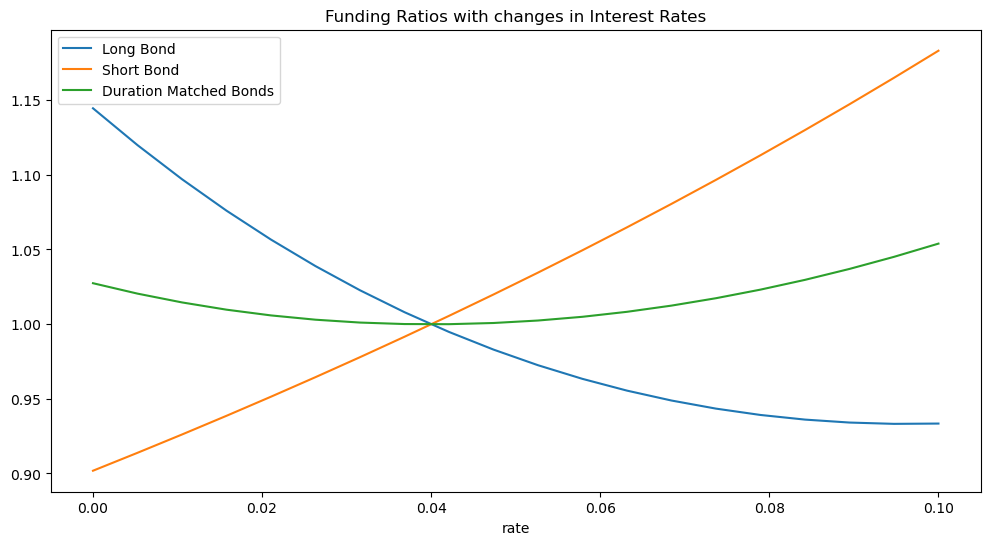

In [48]:
rates = np.linspace(0, .1, 20)
lb_assets = a_0 * long_bond / p_long
sb_assets = a_0 * short_bond / p_short
fr_change = pd.DataFrame({
    'Long Bond': [rk.funding_ratio(lb_assets, liabilities, r) for r in rates],
    'Short Bond': [rk.funding_ratio(sb_assets, liabilities, r) for r in rates],
    'Duration Matched Bonds': [rk.funding_ratio(p_flows, liabilities, r) for r in rates]
}, pd.Index(rates, name='rate'))
fr_change.plot(title = 'Funding Ratios with changes in Interest Rates', figsize = (12 , 6))

In [47]:
fr_change

,Long Bond,Short Bond,Duration Matched Bonds
rate,,,
0.000000,1.144464,0.901852,1.027372
0.005263,1.119809,0.913844,1.020404
0.010526,1.096992,0.926095,1.014512
0.015789,1.075935,0.938613,1.009659
0.021053,1.056570,0.951405,1.005814
0.026316,1.038829,0.964481,1.002946
0.031579,1.022651,0.977851,1.001029
0.036842,1.007979,0.991523,1.000037
0.042105,0.994759,1.005508,0.999947
